### [Measuring Volatility Mean-Reversion](https://medium.com/@crisvelasquez/measuring-volatility-mean-reversion-acd0d93643c3)

> Quantify reversion speeds, regime persistence and visualize when volatility shocks fade or linger.

In [1]:
!pip install -qU yfinance statsmodels

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import yfinance as yf

import matplotlib.pyplot as plt
from matplotlib.dates import MonthLocator, DateFormatter

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression

# 1. Download data
tickers = ['^VIX', '^GSPC']
start, end = '2015-01-01', '2025-07-02'
raw = yf.download(
    tickers,
    start=start,
    end=end,
    progress=False,
    auto_adjust=False
)

# 2. Extract series
vix = raw['Close']['^VIX']
spx = raw['Close']['^GSPC']

# 3. Flatten columns
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)
df = raw.copy()
df.columns = df.columns.map(str.title)

df.head()

Price,Adj Close,Adj Close,Close,Close,High,High,Low,Low,Open,Open,Volume,Volume
Date,,,,,,,,,,,,
2015-01-02,2058.199951,17.790001,2058.199951,17.790001,2072.360107,20.139999,2046.040039,17.049999,2058.899902,17.760000,2708700000,0
2015-01-05,2020.579956,19.920000,2020.579956,19.920000,2054.439941,21.290001,2017.339966,19.190001,2054.439941,19.190001,3799120000,0
2015-01-06,2002.609985,21.120001,2002.609985,21.120001,2030.250000,22.900000,1992.439941,19.520000,2022.150024,20.330000,4460110000,0
2015-01-07,2025.900024,19.309999,2025.900024,19.309999,2029.609985,20.719999,2005.550049,19.040001,2005.550049,20.150000,3805480000,0
2015-01-08,2062.139893,17.010000,2062.139893,17.010000,2064.080078,18.090000,2030.609985,16.990000,2030.609985,17.930000,3934010000,0


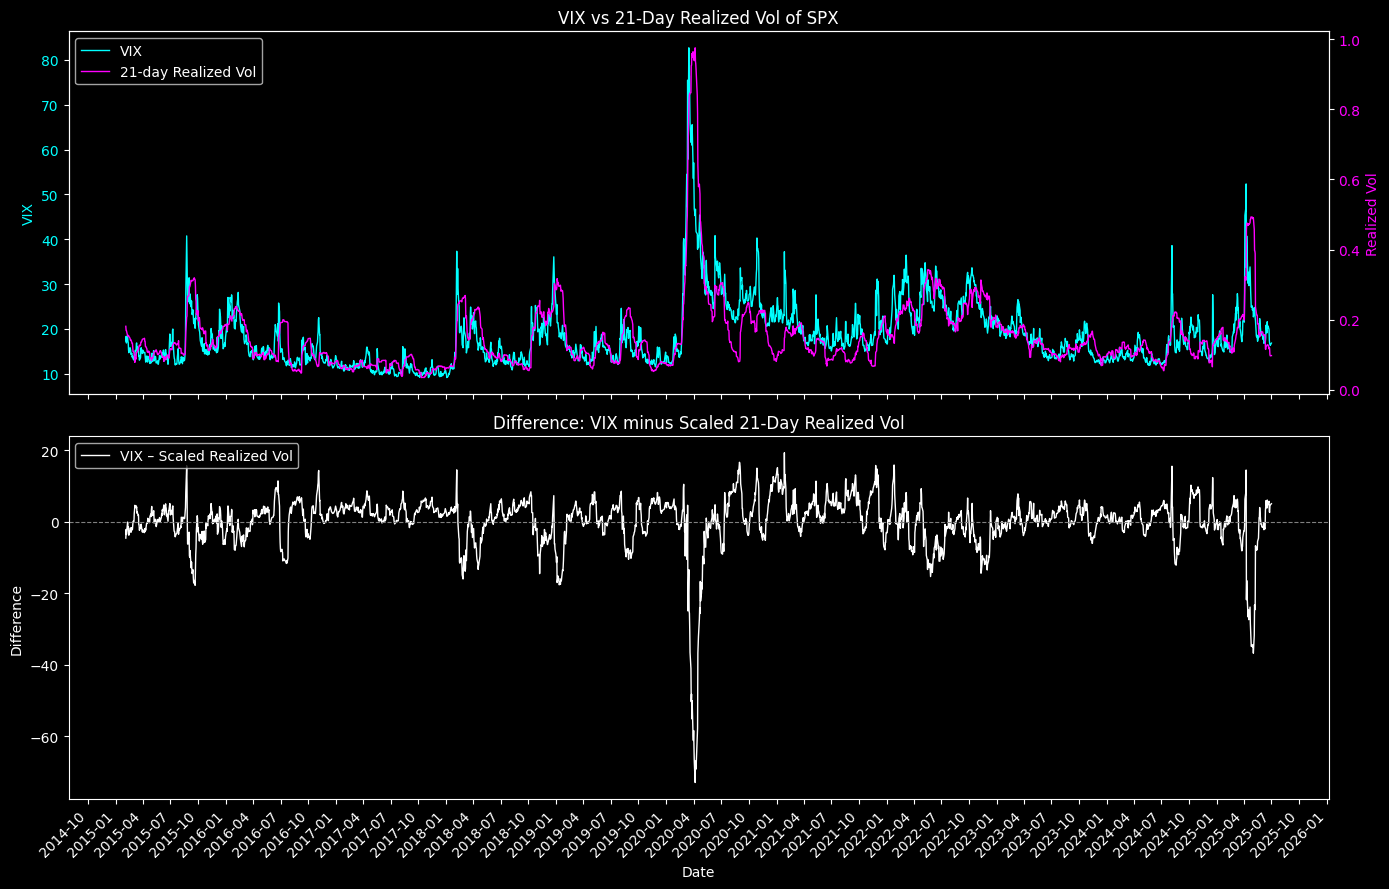

In [4]:
# 4. Compute 21-day realized volatility
window = 21
daily_ret = np.log(spx).diff()
real_vol = daily_ret.rolling(window).std() * np.sqrt(252)
real_vol = real_vol.dropna()

# 5. Align VIX to realized-vol dates
vix = vix.loc[real_vol.index]

# 6. Scale realized vol and compute difference
scale = vix.mean() / real_vol.mean()
real_scaled = real_vol * scale
diff = vix - real_scaled

# 7. Plot both charts as subplots
plt.style.use('dark_background')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# Subplot 1: VIX vs Realized Vol
ax1.plot(vix.index, vix, color='cyan', linewidth=1, label='VIX')
ax1.set_ylabel('VIX', color='cyan')
ax1.tick_params(axis='y', labelcolor='cyan')

ax1b = ax1.twinx()
ax1b.plot(real_vol.index, real_vol,
          color='magenta', linewidth=1,
          label=f'{window}-day Realized Vol')
ax1b.set_ylabel('Realized Vol', color='magenta')
ax1b.tick_params(axis='y', labelcolor='magenta')

lines1, labs1 = ax1.get_legend_handles_labels()
lines1b, labs1b = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines1b, labs1 + labs1b, loc='upper left')
ax1.set_title('VIX vs 21-Day Realized Vol of SPX')

# Subplot 2: Difference (scaled)
ax2.plot(diff.index, diff,
         color='white', linewidth=1,
         label='VIX – Scaled Realized Vol')
ax2.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax2.set_xlabel('Date')
ax2.set_ylabel('Difference')
ax2.legend(loc='upper left')
ax2.set_title('Difference: VIX minus Scaled 21-Day Realized Vol')

# Common X-axis formatting
locator = MonthLocator(bymonth=(1, 4, 7, 10))
formatter = DateFormatter('%Y-%m')
ax2.xaxis.set_major_locator(locator)
ax2.xaxis.set_major_formatter(formatter)
plt.setp(ax2.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

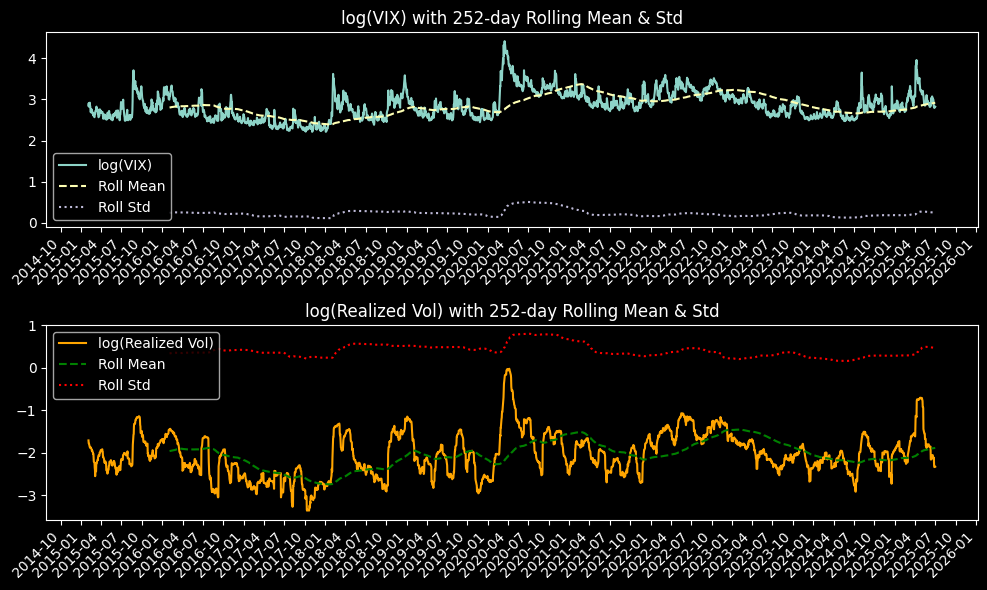

ADF Test on log(VIX):
  Statistic : -4.7875
  p-value   : 0.0001
  Critical Values:
    1%: -3.4329
    5%: -2.8626
    10%: -2.5674
  → Reject H₀: series is stationary (mean-reverting)

ADF Test on log(Realized Vol):
  Statistic : -4.2378
  p-value   : 0.0006
  Critical Values:
    1%: -3.4329
    5%: -2.8627
    10%: -2.5674
  → Reject H₀: series is stationary (mean-reverting)



In [5]:
# 1. Log-transform
log_vix      = np.log(vix)
log_real_vol = np.log(real_vol)

# 2. ADF tests
adf_vix = adfuller(log_vix, autolag='AIC')
adf_rv  = adfuller(log_real_vol, autolag='AIC')

# 3. Plot series and rolling stats
window = 252  # one trading year
fig, axes = plt.subplots(2, 1, figsize=(10, 6))

# log(VIX)
axes[0].plot(log_vix, label='log(VIX)')
axes[0].plot(log_vix.rolling(window).mean(), linestyle='--', label='Roll Mean')
axes[0].plot(log_vix.rolling(window).std(),  linestyle=':', label='Roll Std')
axes[0].set_title('log(VIX) with 252-day Rolling Mean & Std')
axes[0].legend()

# log(Realized Vol)
axes[1].plot(log_real_vol, color='orange', label='log(Realized Vol)')
axes[1].plot(log_real_vol.rolling(window).mean(), linestyle='--', color='green', label='Roll Mean')
axes[1].plot(log_real_vol.rolling(window).std(),  linestyle=':', color='red',   label='Roll Std')
axes[1].set_title('log(Realized Vol) with 252-day Rolling Mean & Std')
axes[1].legend()

# 3b. Quarterly x-axis on both subplots
locator   = MonthLocator(bymonth=(1,4,7,10))  # Jan, Apr, Jul, Oct
formatter = DateFormatter('%Y-%m')            # e.g. "2025-05"
for ax in axes:
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

# 4. Print ADF results with interpretation
alpha = 0.05

def print_adf_with_interp(name, adf_res, alpha=0.05):
    stat, pvalue, usedlag, nobs, crit_vals, icbest = adf_res
    print(f"ADF Test on {name}:")
    print(f"  Statistic : {stat:.4f}")
    print(f"  p-value   : {pvalue:.4f}")
    print("  Critical Values:")
    for lvl, val in crit_vals.items():
        print(f"    {lvl}: {val:.4f}")
    # Interpretation
    if (stat < crit_vals['5%']) and (pvalue < alpha):
        print("  → Reject H₀: series is stationary (mean-reverting)\n")
    else:
        print("  → Fail to reject H₀: series likely has a unit root (no clear mean-reversion)\n")

print_adf_with_interp("log(VIX)",      adf_vix)
print_adf_with_interp("log(Realized Vol)", adf_rv)

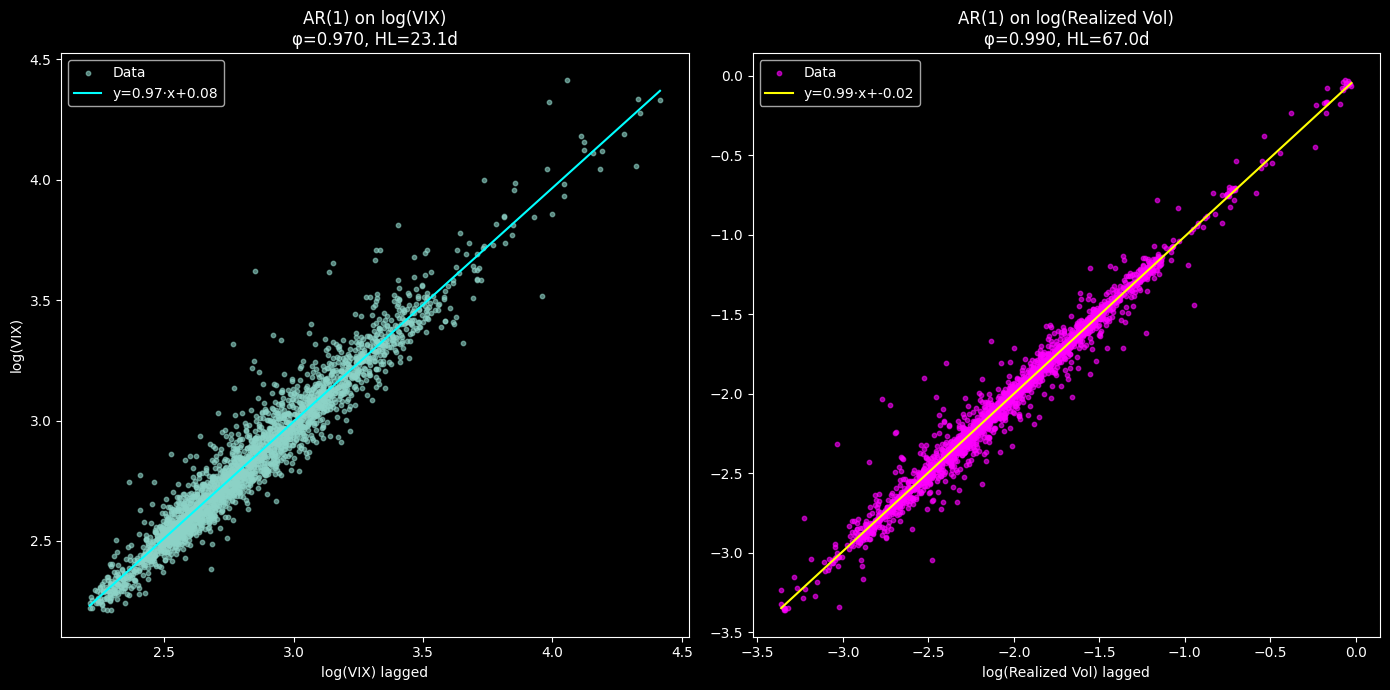

AR(1) on log(VIX):
  φ         = 0.9704
  Half-life = 23.1 days
  → A one-time shock to log(VIX) decays by half after about 23.1 trading days.
  → |φ| < 1: log(VIX) is stationary (mean-reverting)

AR(1) on log(Realized Vol):
  φ         = 0.9897
  Half-life = 67.0 days
  → A one-time shock to log(Realized Vol) decays by half after about 67.0 trading days.
  → |φ| < 1: log(Realized Vol) is stationary (mean-reverting)



In [6]:
# Re-define log series
log_vix      = np.log(vix)
log_real_vol = np.log(real_vol)

def estimate_ar1(series):
    y      = series.dropna()
    y_lag  = y.shift(1).dropna()
    y      = y.loc[y_lag.index]
    X      = sm.add_constant(y_lag)
    res    = sm.OLS(y, X).fit()
    return res.params['const'], res.params[1]

# Estimate parameters and half-lives
const_vix, phi_vix = estimate_ar1(log_vix)
hl_vix             = -np.log(2) / np.log(phi_vix)

const_rv, phi_rv   = estimate_ar1(log_real_vol)
hl_rv              = -np.log(2) / np.log(phi_rv)

# 1. Plot scatter + regression
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# log(VIX)
y     = log_vix.dropna()
y_lag = y.shift(1).dropna()
y     = y.loc[y_lag.index]
axes[0].scatter(y_lag, y, s=10, alpha=0.6, label='Data')
x_line = np.linspace(y_lag.min(), y_lag.max(), 100)
axes[0].plot(
    x_line,
    const_vix + phi_vix * x_line,
    color='cyan',
    label=f'y={phi_vix:.2f}·x+{const_vix:.2f}'
)
axes[0].set_title(f'AR(1) on log(VIX)\nφ={phi_vix:.3f}, HL={hl_vix:.1f}d')
axes[0].set_xlabel('log(VIX) lagged')
axes[0].set_ylabel('log(VIX)')
axes[0].legend()

# log(Realized Vol)
y     = log_real_vol.dropna()
y_lag = y.shift(1).dropna()
y     = y.loc[y_lag.index]
axes[1].scatter(y_lag, y, s=10, alpha=0.6, color='magenta', label='Data')
x_line = np.linspace(y_lag.min(), y_lag.max(), 100)
axes[1].plot(
    x_line,
    const_rv + phi_rv * x_line,
    color='yellow',
    label=f'y={phi_rv:.2f}·x+{const_rv:.2f}'
)
axes[1].set_title(f'AR(1) on log(Realized Vol)\nφ={phi_rv:.3f}, HL={hl_rv:.1f}d')
axes[1].set_xlabel('log(Realized Vol) lagged')
axes[1].legend()

plt.tight_layout()
plt.show()

# 2. Print & interpret log(VIX)
print("AR(1) on log(VIX):")
print(f"  φ         = {phi_vix:.4f}")
print(f"  Half-life = {hl_vix:.1f} days")
print(f"  → A one-time shock to log(VIX) decays by half after about {hl_vix:.1f} trading days.")
if abs(phi_vix) < 1:
    print("  → |φ| < 1: log(VIX) is stationary (mean-reverting)\n")
else:
    print("  → |φ| ≥ 1: log(VIX) is non-stationary (no mean-reversion)\n")

# 2. Print & interpret log(Realized Vol)
print("AR(1) on log(Realized Vol):")
print(f"  φ         = {phi_rv:.4f}")
print(f"  Half-life = {hl_rv:.1f} days")
print(f"  → A one-time shock to log(Realized Vol) decays by half after about {hl_rv:.1f} trading days.")
if abs(phi_rv) < 1:
    print("  → |φ| < 1: log(Realized Vol) is stationary (mean-reverting)\n")
else:
    print("  → |φ| ≥ 1: log(Realized Vol) is non-stationary (no mean-reversion)\n")

OU fit on log(VIX):
  κ         = 0.0296
  μ (long-run mean) = 2.8513
  σ (shock volatility)= 0.0804
  Half-life = 23.4 days
  → κ > 0: process is mean-reverting toward μ.
  → A shock decays by half in 23.4 trading days.

OU fit on log(Realized Vol):
  κ         = 0.0103
  μ (long-run mean) = -2.0544
  σ (shock volatility)= 0.0737
  Half-life = 67.3 days
  → κ > 0: process is mean-reverting toward μ.
  → A shock decays by half in 67.3 trading days.

Median OU half-life over history:
  log(VIX)          = 10.1 days
  log(Realized Vol) = 37.7 days
  → On average, log(VIX) mean-reverts faster than log(Realized Vol).



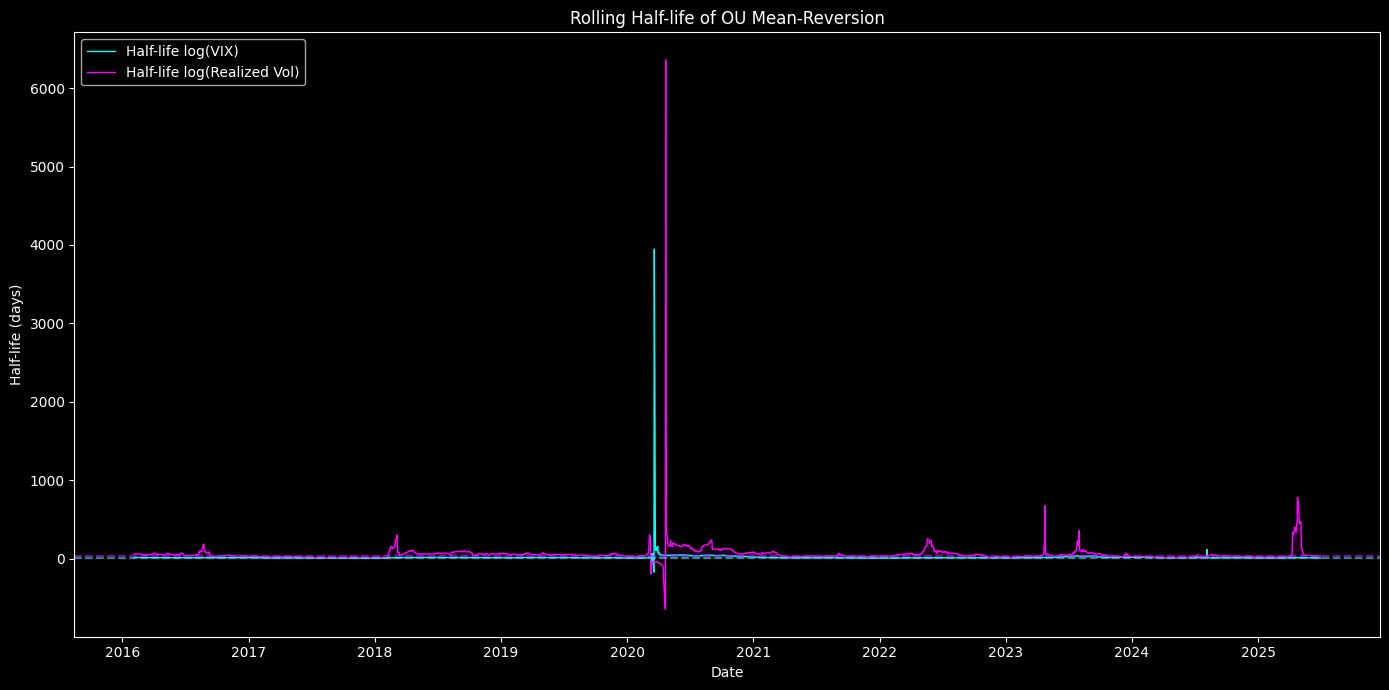

interpretation:
• Baseline half-life clusters around 10–38 days,
  meaning volatility shocks usually lose half their impact within one to two weeks.
• Occasional spikes (up to 3947 d for VIX and 6361 d for Realized Vol)
  correspond to crisis windows when mean-reversion temporarily vanishes.
• Realized volatility shows taller and more frequent spikes, confirming
  that implied volatility (VIX) reverts faster than the actual price variance it forecasts.


In [7]:
# --- OU and rolling half-life analysis with interpretation
# Rebuild log series
log_vix      = np.log(vix)
log_real_vol = np.log(real_vol)

def estimate_ou_params(x):
    x = x.dropna()
    dx = x.diff().dropna()
    x_lag = x.shift(1).loc[dx.index]
    X = sm.add_constant(x_lag)
    res = sm.OLS(dx, X).fit()
    a = res.params['const']
    b = res.params[x_lag.name]
    κ = -b
    μ = a / κ
    σ = res.resid.std()
    hl = np.log(2) / κ
    return κ, μ, σ, hl

# OU parameter estimates
κ_vix, μ_vix, σ_vix, hl_vix_ou = estimate_ou_params(log_vix)
κ_rv,  μ_rv,  σ_rv,  hl_rv_ou  = estimate_ou_params(log_real_vol)

# Print OU results with interpretation
print("OU fit on log(VIX):")
print(f"  κ         = {κ_vix:.4f}")
print(f"  μ (long-run mean) = {μ_vix:.4f}")
print(f"  σ (shock volatility)= {σ_vix:.4f}")
print(f"  Half-life = {hl_vix_ou:.1f} days")
if κ_vix > 0:
    print("  → κ > 0: process is mean-reverting toward μ.")
    print(f"  → A shock decays by half in {hl_vix_ou:.1f} trading days.\n")
else:
    print("  → κ ≤ 0: no mean-reversion detected.\n")

print("OU fit on log(Realized Vol):")
print(f"  κ         = {κ_rv:.4f}")
print(f"  μ (long-run mean) = {μ_rv:.4f}")
print(f"  σ (shock volatility)= {σ_rv:.4f}")
print(f"  Half-life = {hl_rv_ou:.1f} days")
if κ_rv > 0:
    print("  → κ > 0: process is mean-reverting toward μ.")
    print(f"  → A shock decays by half in {hl_rv_ou:.1f} trading days.\n")
else:
    print("  → κ ≤ 0: no mean-reversion detected.\n")

# Rolling half-life series
window = 252
dates  = log_vix.index[window:]

def estimate_half_life(x):
    x = x.dropna()
    dx = x.diff().dropna()
    x_lag = x.shift(1).loc[dx.index]
    X = sm.add_constant(x_lag)
    res = sm.OLS(dx, X).fit()
    κ = -res.params[x_lag.name]
    return np.log(2) / κ

hl_vix = [estimate_half_life(log_vix.iloc[i-window:i]) for i in range(window, len(log_vix))]
hl_rv  = [estimate_half_life(log_real_vol.iloc[i-window:i]) for i in range(window, len(log_real_vol))]

hl_vix_ts = pd.Series(hl_vix, index=dates)
hl_rv_ts  = pd.Series(hl_rv,  index=dates)

# Median half-life interpretation
med_vix = hl_vix_ts.median()
med_rv  = hl_rv_ts.median()
print(f"Median OU half-life over history:")
print(f"  log(VIX)          = {med_vix:.1f} days")
print(f"  log(Realized Vol) = {med_rv:.1f} days")
if med_vix < med_rv:
    print("  → On average, log(VIX) mean-reverts faster than log(Realized Vol).\n")
else:
    print("  → On average, log(Realized Vol) mean-reverts faster than log(VIX).\n")

# Plot rolling half-life
fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(hl_vix_ts, label='Half-life log(VIX)', color='cyan', linewidth=1)
ax.plot(hl_rv_ts,  label='Half-life log(Realized Vol)', color='magenta', linewidth=1)
ax.axhline(med_vix, color='cyan', linestyle='--', alpha=0.6)
ax.axhline(med_rv,  color='magenta', linestyle='--', alpha=0.6)
ax.fill_between(hl_vix_ts.index, hl_vix_ts, med_vix,
                where=hl_vix_ts > med_vix, color='cyan', alpha=0.1)
ax.fill_between(hl_rv_ts.index, hl_rv_ts, med_rv,
                where=hl_rv_ts > med_rv, color='magenta', alpha=0.1)
ax.set_title('Rolling Half-life of OU Mean-Reversion')
ax.set_xlabel('Date')
ax.set_ylabel('Half-life (days)')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

# ─── Narrative interpretation of the chart ───
baseline_vix = med_vix
baseline_rv  = med_rv
spike_vix    = hl_vix_ts.max()
spike_rv     = hl_rv_ts.max()

print("interpretation:")
print(f"• Baseline half-life clusters around {baseline_vix:.0f}–{baseline_rv:.0f} days,")
print("  meaning volatility shocks usually lose half their impact within one to two weeks.")
print(f"• Occasional spikes (up to {spike_vix:.0f} d for VIX and {spike_rv:.0f} d for Realized Vol)")
print("  correspond to crisis windows when mean-reversion temporarily vanishes.")
print("• Realized volatility shows taller and more frequent spikes, confirming")
print("  that implied volatility (VIX) reverts faster than the actual price variance it forecasts.")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)



Estimated transition probabilities (rows = to, cols = from)
          from Reg-0   from Reg-1
to Reg-0   0.9843       0.0107
to Reg-1   0.0157       0.9893

Interpretation:
• Low-vol regime (Reg-0) persistence = 98.43%. Avg spell ≈ 63.7 trading days.
• High-vol regime (Reg-1) persistence = 98.93%. Avg spell ≈ 93.2 trading days.
• Chance of jumping LOW → HIGH next day = 1.57%.
• Chance of jumping HIGH → LOW next day = 1.07%.


                        Markov Switching Model Results                        
Dep. Variable:                  ^GSPC   No. Observations:                 2618
Model:               MarkovRegression   Log Likelihood                -776.773
Date:                Thu, 02 Oct 2025   AIC                           1565.546
Time:                        20:12:25   BIC                           1600.767
Sample:                             0   HQIC                          1578.303
                               - 2618                                         
Covariance Type:

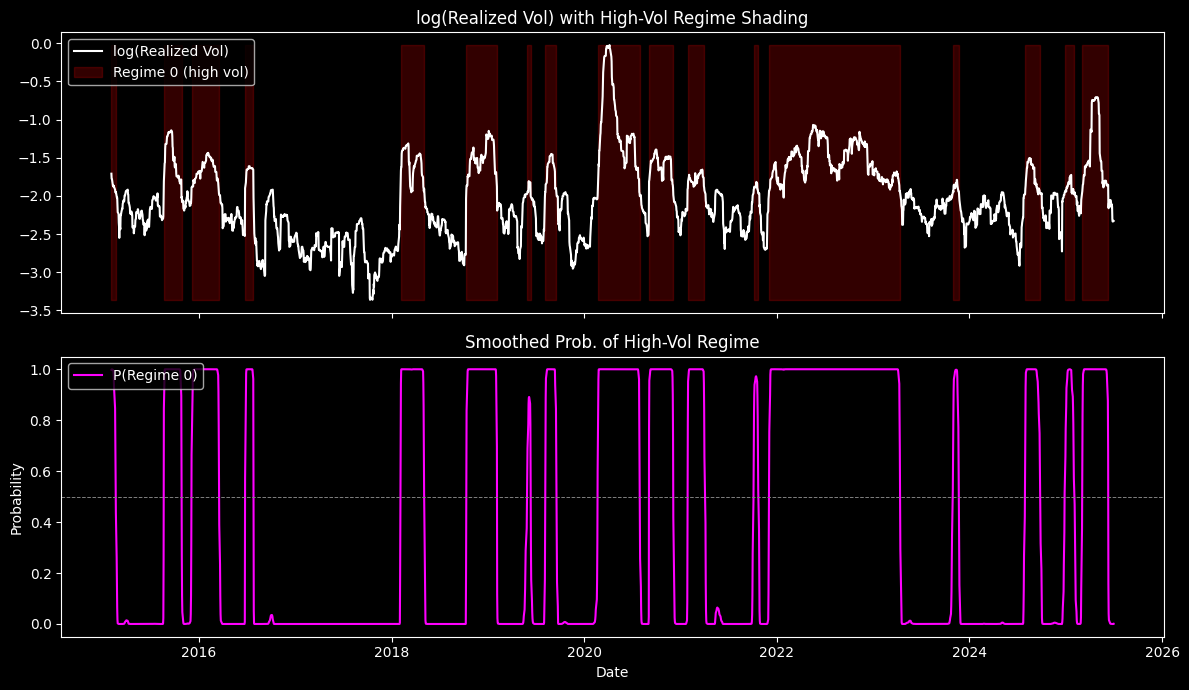

In [8]:
# 1. Prepare series
series = np.log(real_vol)

# 2. Fit 2-regime model
ms  = MarkovRegression(series, k_regimes=2,
                       trend='c', switching_variance=True)
res = ms.fit(disp=False)

# 3. Smoothed probabilities
p = res.smoothed_marginal_probabilities  # DataFrame with cols [0,1]

# 3-b. Transition matrix + interpretation
trans_mat = res.model.regime_transition_matrix(res.params).squeeze()

# ── Pretty print ───────────────────────────────────────────────
print("\nEstimated transition probabilities (rows = to, cols = from)")
print("          from Reg-0   from Reg-1")
print(f"to Reg-0   {trans_mat[0,0]:.4f}       {trans_mat[0,1]:.4f}")
print(f"to Reg-1   {trans_mat[1,0]:.4f}       {trans_mat[1,1]:.4f}")

# ── Interpret persistence & spell lengths ─────────────────────
p00, p11 = trans_mat[0,0], trans_mat[1,1]
p10, p01 = trans_mat[0,1], trans_mat[1,0]

exp_len_0 = 1 / (1 - p00)            # expected # days in Reg-0 once entered
exp_len_1 = 1 / (1 - p11)            # expected # days in Reg-1 once entered

print("\nInterpretation:")
print(f"• Low-vol regime (Reg-0) persistence = {p00:.2%}. "
      f"Avg spell ≈ {exp_len_0:.1f} trading days.")
print(f"• High-vol regime (Reg-1) persistence = {p11:.2%}. "
      f"Avg spell ≈ {exp_len_1:.1f} trading days.")
print(f"• Chance of jumping LOW → HIGH next day = {p01:.2%}.")
print(f"• Chance of jumping HIGH → LOW next day = {p10:.2%}.\n")

print("\n" + res.summary().as_text())
#print("\nSmoothed Probabilities (Regime 0):")
#print(p[0].head())

# 4. Compute regime-means
mean0 = (series * p[0]).sum() / p[0].sum()
mean1 = (series * p[1]).sum() / p[1].sum()

# 5. Identify high-vol regime
high = 1 if mean1 > mean0 else 0
p_high = p[high]
print(f"\nRegime {high} has the higher mean ({mean1 if high==1 else mean0:.2f}).")

# 6. Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# Top: series with shading
ax1.plot(series, color='white', label='log(Realized Vol)')
ax1.fill_between(series.index, series.min(), series.max(),
                 where=p_high > 0.5, color='red', alpha=0.2,
                 label=f'Regime {high} (high vol)')
ax1.legend(loc='upper left')
ax1.set_title('log(Realized Vol) with High-Vol Regime Shading')

# Bottom: high-vol probability
ax2.plot(p_high, color='magenta', label=f'P(Regime {high})')
ax2.axhline(0.5, color='gray', linestyle='--', linewidth=0.7)
ax2.legend(loc='upper left')
ax2.set_ylabel('Probability')
ax2.set_title('Smoothed Prob. of High-Vol Regime')

plt.xlabel('Date')
plt.tight_layout()
plt.show()